# Base de Vendas — Documentação

## Contexto

Base de dados de uma operação **B2B** (loja vendendo para outras lojas).
Por ser B2B, as transações envolvem volumes altos de produtos por pedido,
o que resulta em ticket médio elevado por transação.

## Tabelas

### produtos — 50 registros
Catálogo de produtos disponíveis para compra e venda.

| Coluna                 | Tipo    | Descrição                              |
|------------------------|---------|----------------------------------------|
| **produto_id**         | INTEGER | Chave primária                         |
| **nome_produto**       | VARCHAR | Nome do produto                        |
| **marca**              | VARCHAR | Marca do produto                       |
| **tipo_produto**       | VARCHAR | Categoria (Eletrônico, Games, etc.)    |
| **preco_compra**       | INTEGER | Preço que a loja paga ao fornecedor    |
| **preco_venda_sugerido** | INTEGER | Preço sugerido de venda ao cliente   |

### lojas — 25 registros
Lojas participantes da rede, distribuídas por regiões do Brasil.

| Coluna      | Tipo    | Descrição                                         |
|-------------|---------|---------------------------------------------------|
| **loja_id**   | INTEGER | Chave primária                                  |
| **nome_loja** | VARCHAR | Nome da loja                                    |
| **regiao**    | VARCHAR | Região geográfica (Norte, Sul, Sudeste, etc.)   |

### transacoes — 5.000 registros
Movimentações de compra e venda realizadas pelas lojas.

| Coluna             | Tipo    | Descrição                                              |
|--------------------|---------|--------------------------------------------------------|
| **transacao_id**   | INTEGER | Chave primária                                         |
| **produto_id**     | INTEGER | FK → produtos                                          |
| **loja_id**        | INTEGER | FK → lojas                                             |
| **data_transacao** | DATE    | Data da transação (formato DD/MM/YYYY)                 |
| **tipo_transacao** | VARCHAR | 'venda' ou 'compra'                                    |
| **quantidade**     | INTEGER | Quantidade de unidades na transação                    |
| **desconto**       | INTEGER | Desconto aplicado na transação (0 a 20, em %)          |
| **metodo_pagamento** | VARCHAR | Transferência, Cartão, Pix ou Boleto                 |
| **custo_transporte** | INTEGER | Custo de frete da transação (pago pela loja)         |

## Nuances importantes

### Tipo de transação
- **compra**: a loja está adquirindo produtos do fornecedor
- **venda**: a loja está vendendo produtos para outra loja (cliente B2B)

### Desconto
O desconto é **por transação**, não por produto. Aplica-se tanto em compras
quanto em vendas. Por ser um inteiro de 0 a 20, deve ser convertido para
fator multiplicativo nas queries:

**preco * (1 - desconto / 100.0)**

### Custo de transporte
O **custo_transporte** é **sempre pago pela loja**, independente do tipo de
transação — tanto ao comprar (receber a mercadoria) quanto ao vender
(entregar ao cliente). O cliente B2B não arca com o frete.

### Preços
Os preços **preco_compra** e **preco_venda_sugerido** estão em **reais inteiros**,
sem centavos. O valor real de uma transação só é obtido após aplicar o desconto
e multiplicar pela quantidade.

## Relacionamentos

produtos ──┐
           ├──< transacoes
lojas    ──┘

- Um produto pode aparecer em muitas transações
- Uma loja pode realizar muitas transações
- Cada transação pertence a exatamente um produto e uma loja

In [79]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from tabulate import tabulate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")

engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    print("Conectado com sucesso")

Conectado com sucesso


#### Na nossa base de vendas temos 3 tabelas : 

**Produtos, clientes e lojas.**

#### Criamos as tabelas no SQL com os comandos : 


```sql
CREATE TABLE IF NOT EXISTS produtos (
    produto_id              INTEGER      NOT NULL,
    nome_produto            VARCHAR(100) NOT NULL,
    marca                   VARCHAR(50)  NOT NULL,
    tipo_produto            VARCHAR(50)  NOT NULL,
    preco_compra            INTEGER      NOT NULL,
    preco_venda_sugerido    INTEGER      NOT NULL,
    CONSTRAINT pk_produtos PRIMARY KEY (produto_id)
);

CREATE TABLE IF NOT EXISTS lojas (
    loja_id    INTEGER     NOT NULL,
    nome_loja  VARCHAR(50) NOT NULL,
    regiao     VARCHAR(50) NOT NULL,
    CONSTRAINT pk_lojas PRIMARY KEY (loja_id)
);

CREATE TABLE IF NOT EXISTS transacoes (
    transacao_id      INTEGER     NOT NULL,
    produto_id        INTEGER     NOT NULL,
    loja_id           INTEGER     NOT NULL,
    data_transacao    DATE        NOT NULL,
    tipo_transacao    VARCHAR(10) NOT NULL,
    quantidade        INTEGER     NOT NULL,
    desconto          INTEGER     NOT NULL DEFAULT 0,
    metodo_pagamento  VARCHAR(20) NOT NULL,
    custo_transporte  INTEGER     NOT NULL,
    CONSTRAINT pk_transacoes    PRIMARY KEY (transacao_id),
    CONSTRAINT fk_trans_produto FOREIGN KEY (produto_id) REFERENCES produtos (produto_id),
    CONSTRAINT fk_trans_loja    FOREIGN KEY (loja_id)    REFERENCES lojas    (loja_id)
);

In [2]:
from sqlalchemy import text

with engine.begin() as conn:
    conn.execute(text("TRUNCATE TABLE transacoes, produtos, lojas RESTART IDENTITY CASCADE"))

    with open("base_vendas.sql", "r", encoding="utf-8") as f:
        sql = f.read()

    conn.execute(text(sql))

### Primeiro contato com as tabelas : 

In [3]:
query = "SELECT * FROM produtos LIMIT 5"
print(tabulate(pd.read_sql(query, engine), headers='keys', tablefmt='fancy_grid'))

╒════╤══════════════╤════════════════╤═════════╤════════════════╤════════════════╤════════════════════════╕
│    │   produto_id │ nome_produto   │ marca   │ tipo_produto   │   preco_compra │   preco_venda_sugerido │
╞════╪══════════════╪════════════════╪═════════╪════════════════╪════════════════╪════════════════════════╡
│  0 │            1 │ Produto_1      │ marca_7 │ Esportes       │            210 │                    250 │
├────┼──────────────┼────────────────┼─────────┼────────────────┼────────────────┼────────────────────────┤
│  1 │            2 │ Produto_2      │ marca_4 │ Eletrônico     │            285 │                    570 │
├────┼──────────────┼────────────────┼─────────┼────────────────┼────────────────┼────────────────────────┤
│  2 │            3 │ Produto_3      │ marca_8 │ Games          │            355 │                    640 │
├────┼──────────────┼────────────────┼─────────┼────────────────┼────────────────┼────────────────────────┤
│  3 │            4 │ Produt

In [4]:
query = "SELECT * FROM lojas LIMIT 5"
print(tabulate(pd.read_sql(query, engine), headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════╤═════════════╤══════════╕
│    │   loja_id │ nome_loja   │ regiao   │
╞════╪═══════════╪═════════════╪══════════╡
│  0 │         1 │ Loja_1      │ Nordeste │
├────┼───────────┼─────────────┼──────────┤
│  1 │         2 │ Loja_2      │ Sul      │
├────┼───────────┼─────────────┼──────────┤
│  2 │         3 │ Loja_3      │ Sudeste  │
├────┼───────────┼─────────────┼──────────┤
│  3 │         4 │ Loja_4      │ Nordeste │
├────┼───────────┼─────────────┼──────────┤
│  4 │         5 │ Loja_5      │ Sudeste  │
╘════╧═══════════╧═════════════╧══════════╛


In [5]:
query = "SELECT * FROM transacoes LIMIT 5"
print(tabulate(pd.read_sql(query, engine), headers='keys', tablefmt='fancy_grid'))

╒════╤════════════════╤══════════════╤═══════════╤══════════════════╤══════════════════╤══════════════╤════════════╤════════════════════╤════════════════════╕
│    │   transacao_id │   produto_id │   loja_id │ data_transacao   │ tipo_transacao   │   quantidade │   desconto │ metodo_pagamento   │   custo_transporte │
╞════╪════════════════╪══════════════╪═══════════╪══════════════════╪══════════════════╪══════════════╪════════════╪════════════════════╪════════════════════╡
│  0 │              1 │           41 │        21 │ 2023-03-10       │ venda            │          145 │          5 │ Transferência      │                170 │
├────┼────────────────┼──────────────┼───────────┼──────────────────┼──────────────────┼──────────────┼────────────┼────────────────────┼────────────────────┤
│  1 │              2 │           36 │        10 │ 2024-11-11       │ venda            │          120 │         15 │ Cartão             │                 50 │
├────┼────────────────┼──────────────┼────────

In [6]:
query = "SELECT MIN(data_transacao) AS mais_antiga, MAX(data_transacao) AS mais_recente FROM transacoes"
print(tabulate(pd.read_sql(query, engine), headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════════╤════════════════╕
│    │ mais_antiga   │ mais_recente   │
╞════╪═══════════════╪════════════════╡
│  0 │ 2022-01-01    │ 2025-12-31     │
╘════╧═══════════════╧════════════════╛


### Exploração dos dados com as queries :

### 1. KPIs (Key Performance Indicators — Indicadores-Chave de Desempenho)

#### Métricas de volume :

In [7]:
query = """
    SELECT
        SUM(quantidade) AS qtd_vendida
    FROM transacoes
    WHERE tipo_transacao = 'venda'
"""
print(tabulate(pd.read_sql(query, engine), headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════════╕
│    │   qtd_vendida │
╞════╪═══════════════╡
│  0 │        247355 │
╘════╧═══════════════╛


Foram vendidos 247355 produtos ao entre 01/01/2022 e 31/12/2025

In [8]:
query = " SELECT SUM(quantidade) AS qtd_comprada FROM transacoes WHERE tipo_transacao = 'compra'"
print(tabulate(pd.read_sql(query,engine), headers='keys', tablefmt='fancy_grid'))

╒════╤════════════════╕
│    │   qtd_comprada │
╞════╪════════════════╡
│  0 │         247580 │
╘════╧════════════════╛


Foram comprados 247580 produtos ao entre 01/01/2022 e 31/12/2025, isso quer dizer que temos 225 produtos em estoque.

### Lucro vs gastos 

custo_compra = (quantidade × preco_compra × (1 - desconto / 100.0)) + custo_transporte

In [9]:
query = """
    SELECT
        SUM(
            (t.quantidade * p.preco_compra * (1 - t.desconto / 100.0))
            + t.custo_transporte
        ) AS total_gasto
    FROM transacoes t
    JOIN produtos p ON p.produto_id = t.produto_id
    WHERE t.tipo_transacao = 'compra'
"""

print(tabulate(
    pd.read_sql(query, engine).map(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")),
    headers='keys',
    tablefmt='fancy_grid'
))

╒════╤═══════════════════╕
│    │ total_gasto       │
╞════╪═══════════════════╡
│  0 │ R$ 201.479.168,75 │
╘════╧═══════════════════╛


In [10]:
query = """
    SELECT
        SUM(
            (t.quantidade * p.preco_venda_sugerido * (1 - t.desconto / 100.0))
            + t.custo_transporte
        ) AS total_ganho
    FROM transacoes t
    JOIN produtos p ON p.produto_id = t.produto_id
    WHERE t.tipo_transacao = 'venda'
"""

print(tabulate(
    pd.read_sql(query, engine).map(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")),
    headers='keys',
    tablefmt='fancy_grid'
))

╒════╤═══════════════════╕
│    │ total_ganho       │
╞════╪═══════════════════╡
│  0 │ R$ 299.276.880,00 │
╘════╧═══════════════════╛


**O faturamento foi portanto :  R$ 97.797.711, isso representa um lucro de 32,68%**

### Ticket médio :
Ticket médio é o valor médio gasto por transação. Responde a pergunta: "em média, quanto vale cada venda?"

ticket médio = SUM(quantidade × preco_venda_sugerido × (1 - desconto / 100.0) + custo_transporte) / COUNT(transacao_id)

In [11]:
query = """
SELECT 
    SUM(t.quantidade * p.preco_venda_sugerido * (1 - t.desconto/100.0) + t.custo_transporte)
    / COUNT(t.transacao_id) AS ticket_medio
FROM transacoes t
JOIN produtos p ON p.produto_id = t.produto_id
WHERE t.tipo_transacao = 'venda';
"""
print(tabulate(pd.read_sql(query,engine), headers='keys', tablefmt='fancy_grid'))

╒════╤════════════════╕
│    │   ticket_medio │
╞════╪════════════════╡
│  0 │         119281 │
╘════╧════════════════╛


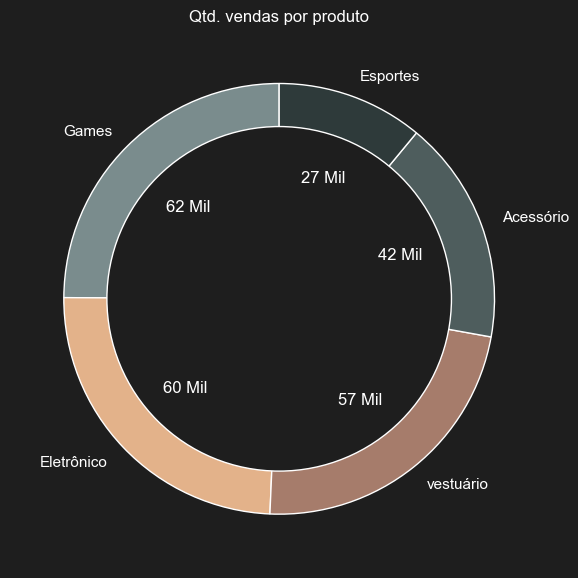

In [19]:

sns.set_theme(style="dark")


query = """
SELECT tipo_produto, SUM(quantidade) as total
FROM transacoes t 
JOIN produtos p ON t.produto_id = p.produto_id
WHERE tipo_transacao = 'venda'
GROUP BY tipo_produto
"""

df = pd.read_sql(query, engine)
df = df.sort_values(by="total", ascending=False)

labels = df["tipo_produto"]
sizes = df["total"]

colors = ["#7A8C8D", "#E3B28A", "#A67C6B", "#4E5D5D", "#2E3A3A"]

def format_values(values):
    def inner(pct):
        total = sum(values)
        val = int(pct * total / 100.0)
        return f"{val/1000:.0f} Mil"
    return inner

fig, ax = plt.subplots(figsize=(6,6), facecolor="#1e1e1e")

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=format_values(sizes),
    startangle=90,
    textprops={'color': 'white'}
)

centre_circle = plt.Circle((0, 0), 0.8, fc='#1e1e1e')
fig.gca().add_artist(centre_circle)

ax.set_title("Qtd. vendas por produto", color="white")

plt.tight_layout()
plt.show()

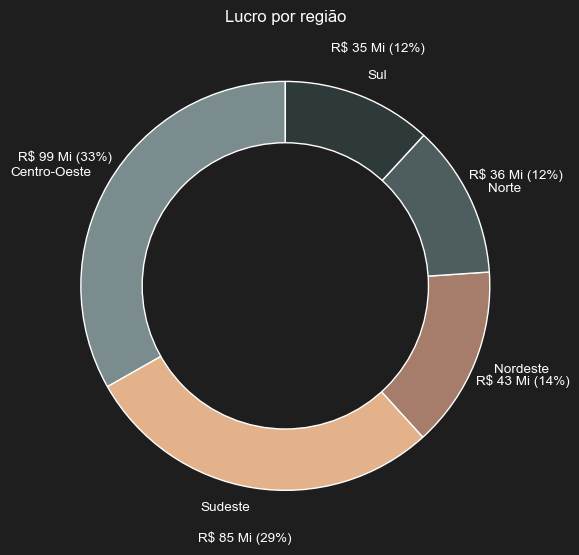

In [78]:
sns.set_theme(style="dark")

query = """
SELECT 
    l.regiao,
    SUM(
        (t.quantidade * p.preco_venda_sugerido - t.custo_transporte) 
        * (1 - t.desconto / 100.0)
    ) AS lucro
FROM transacoes t
JOIN produtos p ON t.produto_id = p.produto_id
JOIN lojas l ON t.loja_id = l.loja_id
WHERE t.tipo_transacao = 'venda'
GROUP BY l.regiao
ORDER BY lucro DESC
"""

df = pd.read_sql(query, engine)

labels = df["regiao"]
sizes = df["lucro"]

colors = ["#7A8C8D", "#E3B28A", "#A67C6B", "#4E5D5D", "#2E3A3A"]

def format_values(values):
    def inner(pct):
        total = sum(values)
        val = pct * total / 100.0
        return f"R$ {val/1_000_000:.0f} Mi ({pct:.0f}%)"
    return inner

fig, ax = plt.subplots(figsize=(6, 6), facecolor="#1e1e1e")

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=format_values(sizes),
    startangle=90,
    pctdistance=1.25,
    wedgeprops=dict(width=0.6),
    textprops={'color': 'white', 'fontsize': 9.7}
)

centre_circle = plt.Circle((0, 0), 0.7, fc='#1e1e1e')
fig.gca().add_artist(centre_circle)

ax.set_title("Lucro por região", color="white")

plt.tight_layout()
plt.show()

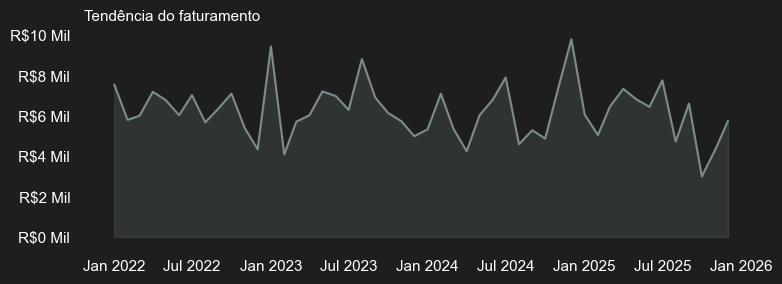

In [89]:
sns.set_theme(style="dark")

query = """
SELECT 
    DATE_TRUNC('month', t.data_transacao) AS mes,
    SUM(
        (t.quantidade * p.preco_venda_sugerido - t.custo_transporte) 
        * (1 - t.desconto / 100.0)
    ) AS faturamento
FROM transacoes t
JOIN produtos p ON t.produto_id = p.produto_id
WHERE t.tipo_transacao = 'venda'
GROUP BY mes
ORDER BY mes
"""

df = pd.read_sql(query, engine)
df["mes"] = pd.to_datetime(df["mes"])

fig, ax = plt.subplots(figsize=(8, 3), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R${x/1000000:.0f} Mil"))


ax.plot(df["mes"], df["faturamento"], color="#7A8C8D", linewidth=1.5)
ax.fill_between(df["mes"], df["faturamento"], alpha=0.2, color="#7A8C8D")

ax.set_title("Tendência do faturamento", color="white", loc="left", fontsize=11)

ax.tick_params(colors="white")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

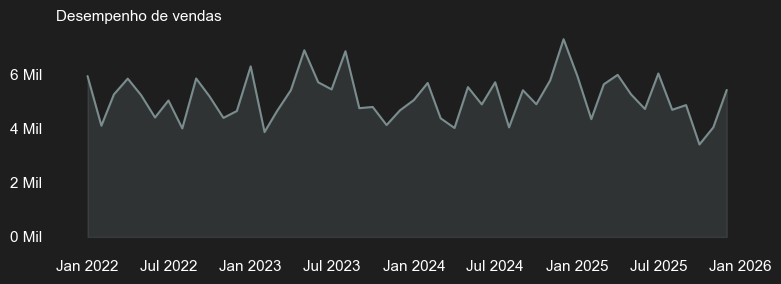

In [90]:
sns.set_theme(style="dark")

query = """
SELECT 
    DATE_TRUNC('month', t.data_transacao) AS mes,
    SUM(t.quantidade) AS quantidade
FROM transacoes t
WHERE t.tipo_transacao = 'venda'
GROUP BY mes
ORDER BY mes
"""

df = pd.read_sql(query, engine)
df["mes"] = pd.to_datetime(df["mes"])

fig, ax = plt.subplots(figsize=(8, 3), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

ax.plot(df["mes"], df["quantidade"], color="#7A8C8D", linewidth=1.5)
ax.fill_between(df["mes"], df["quantidade"], alpha=0.2, color="#7A8C8D")

ax.set_title("Desempenho de vendas", color="white", loc="left", fontsize=11)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f} Mil"))
ax.tick_params(colors="white")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

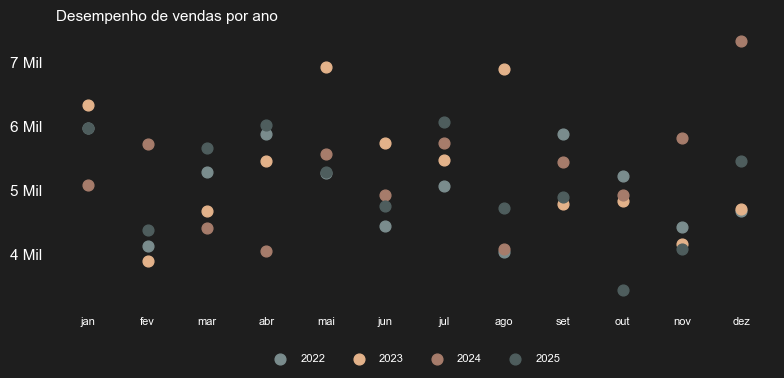

In [92]:
sns.set_theme(style="dark")

query = """
SELECT 
    EXTRACT(year FROM t.data_transacao) AS ano,
    EXTRACT(month FROM t.data_transacao) AS mes,
    SUM(t.quantidade) AS quantidade
FROM transacoes t
WHERE t.tipo_transacao = 'venda'
GROUP BY ano, mes
ORDER BY ano, mes
"""

df = pd.read_sql(query, engine)
df["ano"] = df["ano"].astype(int)
df["mes"] = df["mes"].astype(int)

colors = ["#7A8C8D", "#E3B28A", "#A67C6B", "#4E5D5D", "#2E3A3A"]
anos = sorted(df["ano"].unique())

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

for i, ano in enumerate(anos):
    df_ano = df[df["ano"] == ano]
    ax.scatter(df_ano["mes"], df_ano["quantidade"], 
               color=colors[i % len(colors)], label=str(ano), s=60)

ax.set_title("Desempenho de vendas por ano", color="white", loc="left", fontsize=11)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"], 
                   color="white", fontsize=8)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f} Mil"))
ax.tick_params(colors="white")

ax.legend(frameon=False, labelcolor="white", fontsize=8,
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(anos))

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

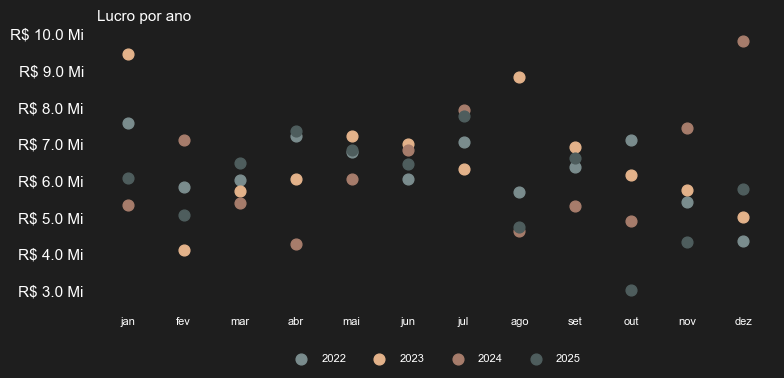

In [ ]:
sns.set_theme(style="dark")

query = """
SELECT 
    EXTRACT(year FROM t.data_transacao) AS ano,
    EXTRACT(month FROM t.data_transacao) AS mes,
    SUM(
        (t.quantidade * p.preco_venda_sugerido - t.custo_transporte) 
        * (1 - t.desconto / 100.0)
    ) AS lucro
FROM transacoes t
JOIN produtos p ON t.produto_id = p.produto_id
WHERE t.tipo_transacao = 'venda'
GROUP BY ano, mes
ORDER BY ano, mes
"""

df = pd.read_sql(query, engine)
df["ano"] = df["ano"].astype(int)
df["mes"] = df["mes"].astype(int)

colors = ["#7A8C8D", "#E3B28A", "#A67C6B", "#4E5D5D", "#2E3A3A"]
anos = sorted(df["ano"].unique())

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

for i, ano in enumerate(anos):
    df_ano = df[df["ano"] == ano]
    ax.scatter(df_ano["mes"], df_ano["lucro"],
               color=colors[i % len(colors)], label=str(ano), s=40, alpha=0.8)

ax.set_title("Lucro por ano", color="white", loc="left", fontsize=11)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"],
                   color="white", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x/1_000_000:.1f} Mi"))
ax.tick_params(colors="white")
ax.legend(frameon=False, labelcolor="white", fontsize=8,
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(anos))

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

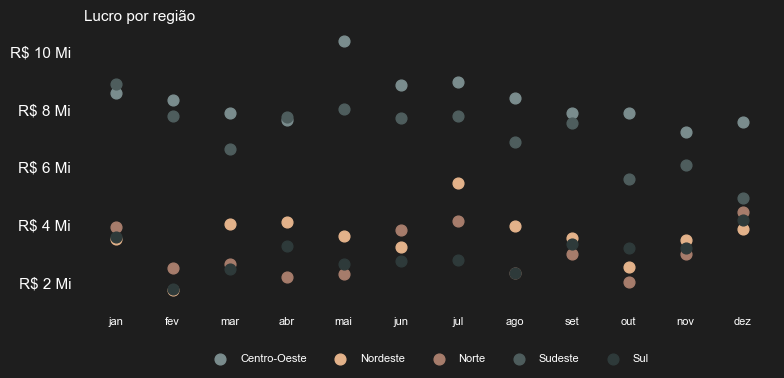

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="dark")

query = """
SELECT 
    l.regiao,
    EXTRACT(month FROM t.data_transacao) AS mes,
    SUM(
        (t.quantidade * p.preco_venda_sugerido - t.custo_transporte) 
        * (1 - t.desconto / 100.0)
    ) AS lucro
FROM transacoes t
JOIN produtos p ON t.produto_id = p.produto_id
JOIN lojas l ON t.loja_id = l.loja_id
WHERE t.tipo_transacao = 'venda'
GROUP BY l.regiao, mes
ORDER BY l.regiao, mes
"""

df = pd.read_sql(query, engine)
df["mes"] = df["mes"].astype(int)
df = df.sort_values(["regiao", "mes"])


colors = ["#7A8C8D", "#E3B28A", "#A67C6B", "#4E5D5D", "#2E3A3A"]
regioes = sorted(df["regiao"].unique())

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

for i, regiao in enumerate(regioes):
    df_regiao = df[df["regiao"] == regiao]

    ax.scatter(
        df_regiao["mes"],
        df_regiao["lucro"],
        color=colors[i % len(colors)],
        label=regiao,
        s=60
    )

ax.set_title("Lucro por região", color="white", loc="left", fontsize=11)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"],
    color="white",
    fontsize=8
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R$ {x/1_000_000:.0f} Mi")
)

ax.tick_params(colors="white")

ax.legend(
    frameon=False,
    labelcolor="white",
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(regioes)
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()